
SAE (Sparse Autoencoder - denso) para cavity_refinado

O que este script faz:
- Lê U (Ux, Uy) do OpenFOAM em múltiplos timesteps
- Interpola para uma grade 2D regular (imagem) via griddata
- Constrói vetor por snapshot: flatten([Ux_grid, Uy_grid]) -> (ny*nx*2,)
- Split temporal (train/val) SEM embaralhar
- Normalização por feature (apenas estatísticas do treino)
- Clipping robusto após normalizar
- Treina SAE denso com penalidade L1 no latente (esparsidade)
- Callbacks: EarlyStopping, ReduceLROnPlateau, Checkpoint
- Diagnósticos + 7+ análises:
  (1) loss/val_loss
  (2) generalization gap
  (3) overfit score (gap/|val|)
  (4) MSE por snapshot (train vs val)
  (5) relL2 por snapshot (train vs val)
  (6) histogramas relL2 train/val
  (7) outliers topK com imagens (Ux/Uy true|recon|err)
  (8) relL2 no físico (desnormalizado)
  (9) latentes z(t) salvos (train/val)
- Salva: modelos, normalização, latentes, métricas .npz, figuras



In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Tuple, Dict, Any

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from scipy.interpolate import griddata
from fluidfoam import readmesh, readfield

Config + Paths

In [ ]:
@dataclass
class SAEConfig:
    case_dir: Path
    out_dir: Path

    nx: int = 64
    ny: int = 64
    padding: float = 0.0
    interp_method: str = "linear"
    n_timesteps: int | None = None

    train_ratio: float = 0.80

    latent_dim: int = 16
    hidden: list[int] | None = None
    lr: float = 3e-4
    epochs: int = 200
    batch: int = 32
    shuffle: bool = True

    l1_latent: float = 1e-7
    dropout: float = 0.0
    clip_zscore: float | None = 4.0
    use_huber: bool = True
    huber_delta: float = 1.0

    early_patience: int = 20
    plateau_patience: int = 8

    outlier_topk: int = 5
    save_outlier_images: bool = True
    seed: int = 123

    tag: str = "sae_dense"

    def __post_init__(self):
        if self.hidden is None:
            self.hidden = [256, 128]


# >>>>>>> AJUSTE AQUI <<<<<<<
CASE_DIR = Path(r"C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\cavity1000")  # tem constant/, system/, 0/, ...

OUT_DIR = CASE_DIR / "SAE" / "resultados" / "SAE"
OUT_DIR.mkdir(parents=True, exist_ok=True)

poly = CASE_DIR / "constant" / "polyMesh"
if not poly.exists():
    raise FileNotFoundError(f"CASE_DIR inválido: não achei {poly}\nCASE_DIR={CASE_DIR.resolve()}")

cfg = SAEConfig(case_dir=CASE_DIR.resolve(), out_dir=OUT_DIR.resolve())
print("✅ CASE_DIR:", cfg.case_dir)
print("✅ OUT_DIR :", cfg.out_dir)
print("✅ cfg:", cfg)

✅ CASE_DIR: C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\cavity_refinado
✅ OUT_DIR : C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\cavity_refinado\SAE\resultados\SAE
✅ cfg: SAEConfig(case_dir=WindowsPath('C:/Users/eldoj/OneDrive/Documentos/SAE-POD-SINDy-main/cavity_refinado'), out_dir=WindowsPath('C:/Users/eldoj/OneDrive/Documentos/SAE-POD-SINDy-main/cavity_refinado/SAE/resultados/SAE'), nx=64, ny=64, padding=0.0, interp_method='linear', n_timesteps=None, train_ratio=0.8, latent_dim=16, hidden=[256, 128], lr=0.0003, epochs=200, batch=32, shuffle=True, l1_latent=1e-07, dropout=0.0, clip_zscore=4.0, use_huber=True, huber_delta=1.0, early_patience=20, plateau_patience=8, outlier_topk=5, save_outlier_images=True, seed=123, tag='sae_dense')


Seed

In [3]:
def set_seeds(seed: int) -> None:
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds(cfg.seed)
print("✅ Seeds setadas:", cfg.seed)

✅ Seeds setadas: 123


OpenFOAM → Grids (leitura + interpolação)

In [4]:
def list_time_dirs(case_dir: Path, n_timesteps: int | None = None) -> list[str]:
    case_dir = Path(case_dir)
    times = sorted(
        [d.name for d in case_dir.iterdir()
         if d.is_dir() and d.name.replace(".", "").replace("-", "").isdigit()],
        key=lambda s: float(s),
    )
    if n_timesteps is not None:
        times = times[:n_timesteps]
    return times


def build_regular_grid(xc: np.ndarray, yc: np.ndarray, nx: int, ny: int, padding: float):
    xmin, xmax = float(xc.min()), float(xc.max())
    ymin, ymax = float(yc.min()), float(yc.max())
    dx, dy = xmax - xmin, ymax - ymin
    xmin -= padding * dx; xmax += padding * dx
    ymin -= padding * dy; ymax += padding * dy
    xg = np.linspace(xmin, xmax, nx)
    yg = np.linspace(ymin, ymax, ny)
    Xg, Yg = np.meshgrid(xg, yg)
    return Xg, Yg


def read_U_components(case_dir: Path, time_dir: str, nCells: int):
    Uf = np.asarray(readfield(str(case_dir), time_dir, "U"))

    if Uf.ndim == 2 and Uf.shape == (3, 1):  # uniforme
        Ux = np.full(nCells, float(Uf[0, 0]), dtype=float)
        Uy = np.full(nCells, float(Uf[1, 0]), dtype=float)
        return Ux, Uy

    if Uf.ndim == 2 and Uf.shape[0] == 3 and Uf.shape[1] == nCells:
        return Uf[0, :].astype(float), Uf[1, :].astype(float)

    if Uf.ndim == 2 and Uf.shape[0] == nCells and Uf.shape[1] >= 2:
        return Uf[:, 0].astype(float), Uf[:, 1].astype(float)

    if Uf.ndim == 1 and Uf.size == 3 * nCells:
        Uf2 = Uf.reshape(nCells, 3)
        return Uf2[:, 0].astype(float), Uf2[:, 1].astype(float)

    raise ValueError(f"Formato inesperado do U em {time_dir}: Uf.shape={Uf.shape} (nCells={nCells})")


def load_openfoam_as_grids(
    case_dir: Path,
    nx: int,
    ny: int,
    n_timesteps: int | None,
    method: str,
    padding: float,
) -> Tuple[np.ndarray, np.ndarray, Dict[str, Any]]:
    case_dir = Path(case_dir)

    xc, yc, _zc = readmesh(str(case_dir))
    xc = np.asarray(xc).ravel()
    yc = np.asarray(yc).ravel()
    nCells = xc.size

    time_dirs = list_time_dirs(case_dir, n_timesteps=n_timesteps)
    Xg, Yg = build_regular_grid(xc, yc, nx=nx, ny=ny, padding=padding)
    pts = np.column_stack([xc, yc])

    X_list, t_list = [], []
    nan_fill_ratio = []

    print(f"📂 Timesteps encontrados: {len(time_dirs)}")
    for td in time_dirs:
        try:
            Ux, Uy = read_U_components(case_dir, td, nCells=nCells)

            Uxg = griddata(pts, Ux, (Xg, Yg), method=method)
            Uyg = griddata(pts, Uy, (Xg, Yg), method=method)

            nan_before = 0.5 * (np.mean(np.isnan(Uxg)) + np.mean(np.isnan(Uyg)))
            nan_fill_ratio.append(float(nan_before))

            if np.isnan(Uxg).any() or np.isnan(Uyg).any():
                Uxg_near = griddata(pts, Ux, (Xg, Yg), method="nearest")
                Uyg_near = griddata(pts, Uy, (Xg, Yg), method="nearest")
                Uxg = np.where(np.isnan(Uxg), Uxg_near, Uxg)
                Uyg = np.where(np.isnan(Uyg), Uyg_near, Uyg)

            frame = np.stack([Uxg, Uyg], axis=-1).astype(np.float32)  # (ny,nx,2)
            X_list.append(frame)
            t_list.append(float(td))

            print(f"   ✓ t={td:>10s} | nan_ratio(before fill)={nan_before:.4f}")
        except Exception as e:
            print(f"   ⚠️ erro no timestep {td}: {e}")
            continue

    if len(X_list) == 0:
        raise RuntimeError(
            f"Nenhum timestep v?lido foi carregado em {case_dir}. "
            f"Total encontrado={len(time_dirs)}; verifique fluidfoam/campo U."
        )

    X = np.array(X_list, dtype=np.float32)
    t = np.array(t_list, dtype=np.float32)

    nan_stats = {
        "nan_ratio_mean": float(np.mean(nan_fill_ratio)) if len(nan_fill_ratio) else None,
        "nan_ratio_max": float(np.max(nan_fill_ratio)) if len(nan_fill_ratio) else None,
        "nan_ratio_per_timestep": np.array(nan_fill_ratio, dtype=np.float32),
    }
    return X, t, nan_stats


def time_split(X: np.ndarray, t: np.ndarray, train_ratio: float):
    if not (0.0 < float(train_ratio) < 1.0):
        raise ValueError(f"train_ratio deve estar em (0,1). Recebido: {train_ratio}")

    idx = np.argsort(t)
    Xs = X[idx]
    ts = t[idx]

    n = len(ts)
    if n < 2:
        raise ValueError(f"S?o necess?rios ao menos 2 snapshots para split. Recebido: n={n}")

    n_train = int(round(train_ratio * n))
    n_train = max(1, min(n - 1, n_train))

    return Xs[:n_train], Xs[n_train:], ts[:n_train], ts[n_train:]


OpenFOAM → Grids (leitura + interpolação)

In [5]:
X_img, t, nan_stats = load_openfoam_as_grids(
    case_dir=cfg.case_dir,
    nx=cfg.nx, ny=cfg.ny,
    n_timesteps=cfg.n_timesteps,
    method=cfg.interp_method,
    padding=cfg.padding,
)

print("✅ X_img:", X_img.shape)  # (N, ny, nx, 2)
print("✅ t    :", t.shape)
print("nan_ratio_mean:", nan_stats["nan_ratio_mean"], "nan_ratio_max:", nan_stats["nan_ratio_max"])

np.savez_compressed(cfg.out_dir / "nan_stats.npz", **nan_stats, t=t)
print("✅ Salvo:", cfg.out_dir / "nan_stats.npz")

Reading file C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\cavity_refinado/constant/polyMesh/owner
Reading file C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\cavity_refinado/constant/polyMesh/faces
Reading file C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\cavity_refinado/constant/polyMesh/points
Reading file C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\cavity_refinado/constant/polyMesh/neighbour
📂 Timesteps encontrados: 11
Reading file C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\cavity_refinado\0\U

Only constant field in output

   ✓ t=         0 | nan_ratio(before fill)=0.0000
Reading file C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\cavity_refinado\0.0999799\U
   ✓ t= 0.0999799 | nan_ratio(before fill)=0.0000
Reading file C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\cavity_refinado\0.19998\U
   ✓ t=   0.19998 | nan_ratio(before fill)=0.0000
Reading file C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\cavity_refinado

Carregar dados

Preview (Opção 2: pcolormesh no domínio físico)

Reading file C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\cavity_refinado/constant/polyMesh/owner
Reading file C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\cavity_refinado/constant/polyMesh/faces
Reading file C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\cavity_refinado/constant/polyMesh/points
Reading file C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\cavity_refinado/constant/polyMesh/neighbour


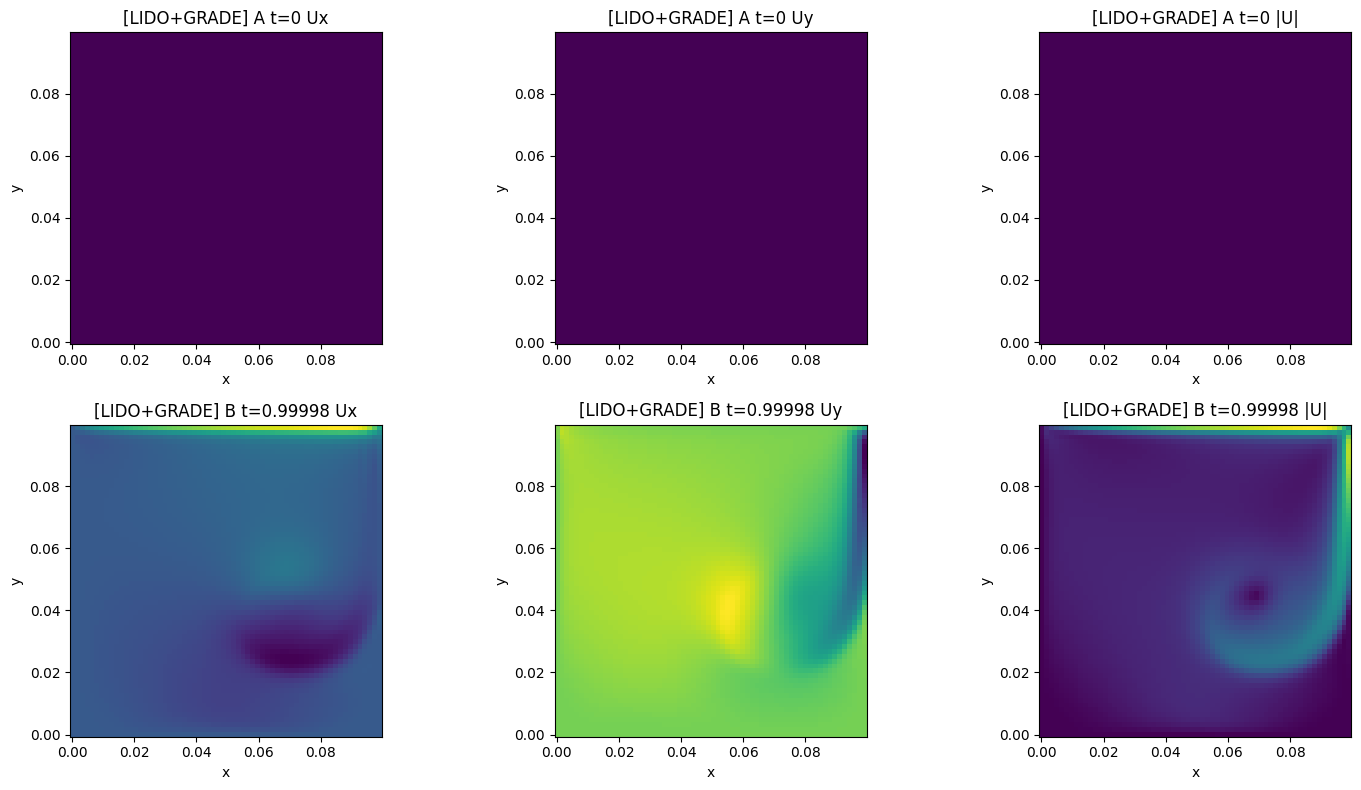

In [7]:
def get_regular_grid_from_case(case_dir: Path, nx: int, ny: int, padding: float):
    xc, yc, _ = readmesh(str(case_dir))
    xc = np.asarray(xc).ravel()
    yc = np.asarray(yc).ravel()
    Xg, Yg = build_regular_grid(xc, yc, nx=nx, ny=ny, padding=padding)
    return Xg, Yg


def plot_two_frames_pcolormesh(
    X_img: np.ndarray,
    t: np.ndarray,
    Xg: np.ndarray,
    Yg: np.ndarray,
    idx_a: int = 0,
    idx_b: int = -1,
    title: str = "",
):
    N = X_img.shape[0]
    ia = idx_a if idx_a >= 0 else N + idx_a
    ib = idx_b if idx_b >= 0 else N + idx_b

    A = X_img[ia]
    B = X_img[ib]

    def mag(frame):
        return np.sqrt(frame[..., 0] ** 2 + frame[..., 1] ** 2)

    fig, ax = plt.subplots(2, 3, figsize=(15, 8))

    ax[0, 0].pcolormesh(Xg, Yg, A[..., 0], shading="auto"); ax[0, 0].set_title(f"{title}A t={t[ia]:.6g} Ux")
    ax[0, 1].pcolormesh(Xg, Yg, A[..., 1], shading="auto"); ax[0, 1].set_title(f"{title}A t={t[ia]:.6g} Uy")
    ax[0, 2].pcolormesh(Xg, Yg, mag(A),    shading="auto"); ax[0, 2].set_title(f"{title}A t={t[ia]:.6g} |U|")

    ax[1, 0].pcolormesh(Xg, Yg, B[..., 0], shading="auto"); ax[1, 0].set_title(f"{title}B t={t[ib]:.6g} Ux")
    ax[1, 1].pcolormesh(Xg, Yg, B[..., 1], shading="auto"); ax[1, 1].set_title(f"{title}B t={t[ib]:.6g} Uy")
    ax[1, 2].pcolormesh(Xg, Yg, mag(B),    shading="auto"); ax[1, 2].set_title(f"{title}B t={t[ib]:.6g} |U|")

    for i in range(2):
        for j in range(3):
            ax[i, j].set_aspect("equal")
            ax[i, j].set_xlabel("x")
            ax[i, j].set_ylabel("y")

    fig.tight_layout()
    plt.show()


# cria a grade física 1x e plota 2 snapshots reais
Xg, Yg = get_regular_grid_from_case(cfg.case_dir, nx=cfg.nx, ny=cfg.ny, padding=cfg.padding)
plot_two_frames_pcolormesh(X_img, t, Xg, Yg, idx_a=0, idx_b=-1, title="[LIDO+GRADE] ")

Reading file C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\cavity_refinado/constant/polyMesh/owner
Reading file C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\cavity_refinado/constant/polyMesh/faces
Reading file C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\cavity_refinado/constant/polyMesh/points
Reading file C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\cavity_refinado/constant/polyMesh/neighbour


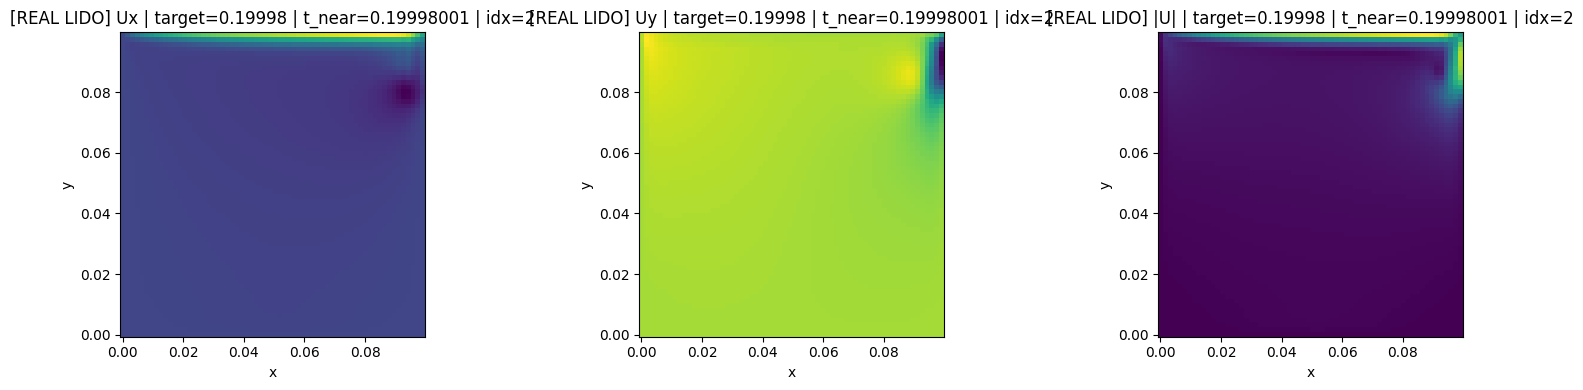

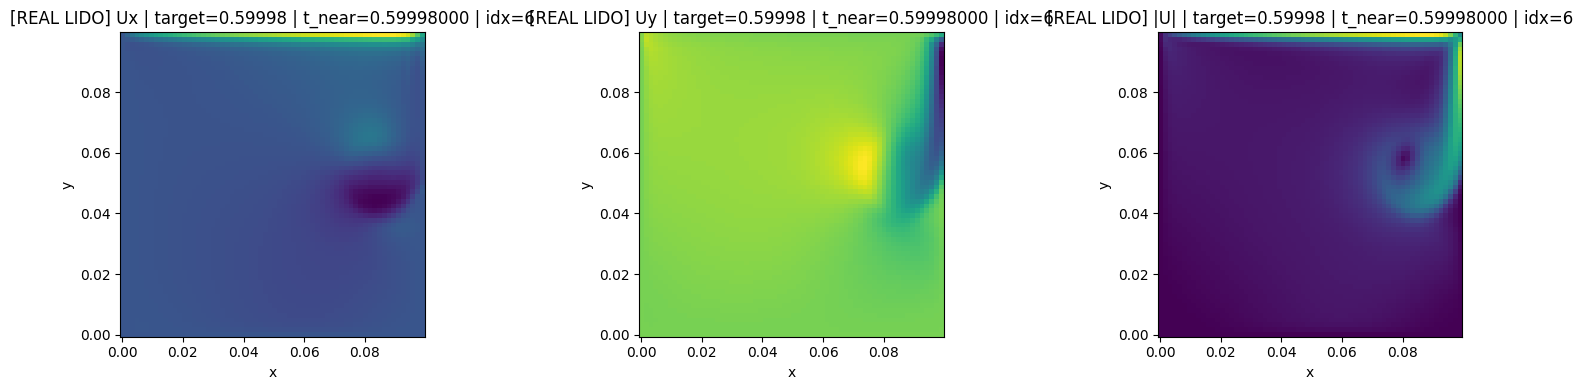

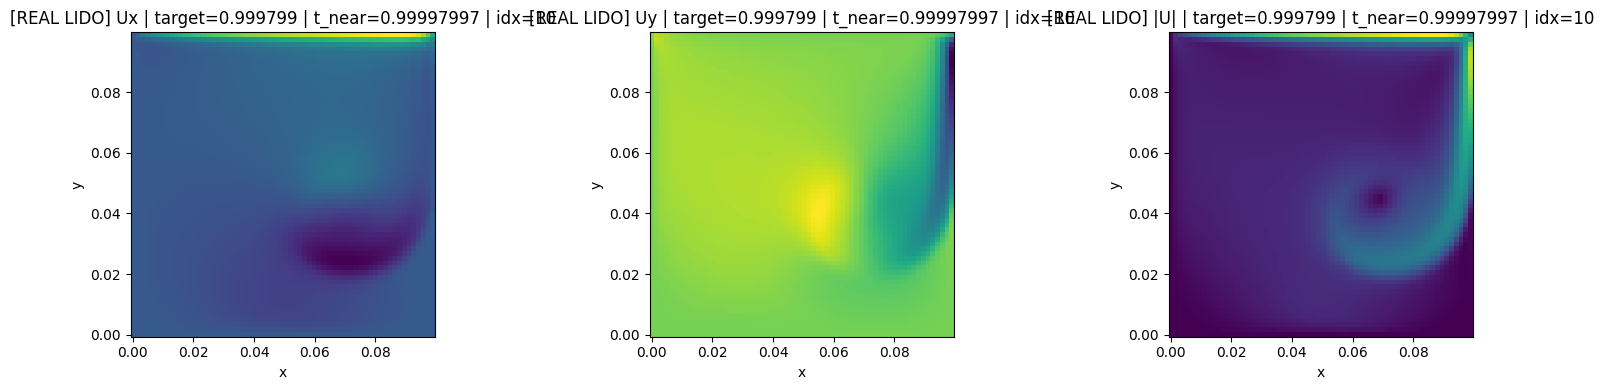

In [8]:
# ============================================================
# Plot do dado REAL lido (X_img) para tempos específicos
# (pcolormesh no domínio físico)
# ============================================================

def find_nearest_time_indices(t: np.ndarray, targets: list[float]) -> list[int]:
    idxs = []
    for tt in targets:
        idx = int(np.argmin(np.abs(t - tt)))
        idxs.append(idx)
    return idxs


def plot_times_pcolormesh(
    X_img: np.ndarray,
    t: np.ndarray,
    case_dir: Path,
    nx: int,
    ny: int,
    padding: float,
    targets: list[float],
    title_prefix: str = "[REAL LIDO] ",
):
    # reconstrói grade física (mesma usada no loader)
    xc, yc, _ = readmesh(str(case_dir))
    xc = np.asarray(xc).ravel()
    yc = np.asarray(yc).ravel()
    Xg, Yg = build_regular_grid(xc, yc, nx=nx, ny=ny, padding=padding)

    idxs = find_nearest_time_indices(t, targets)

    def mag(frame):
        return np.sqrt(frame[..., 0] ** 2 + frame[..., 1] ** 2)

    for target, idx in zip(targets, idxs):
        frame = X_img[idx]  # (ny,nx,2)

        fig, ax = plt.subplots(1, 3, figsize=(16, 4))

        ax[0].pcolormesh(Xg, Yg, frame[..., 0], shading="auto")
        ax[0].set_title(f"{title_prefix}Ux | target={target} | t_near={t[idx]:.8f} | idx={idx}")
        ax[0].set_aspect("equal"); ax[0].set_xlabel("x"); ax[0].set_ylabel("y")

        ax[1].pcolormesh(Xg, Yg, frame[..., 1], shading="auto")
        ax[1].set_title(f"{title_prefix}Uy | target={target} | t_near={t[idx]:.8f} | idx={idx}")
        ax[1].set_aspect("equal"); ax[1].set_xlabel("x"); ax[1].set_ylabel("y")

        ax[2].pcolormesh(Xg, Yg, mag(frame), shading="auto")
        ax[2].set_title(f"{title_prefix}|U| | target={target} | t_near={t[idx]:.8f} | idx={idx}")
        ax[2].set_aspect("equal"); ax[2].set_xlabel("x"); ax[2].set_ylabel("y")

        fig.tight_layout()
        plt.show()


# ---- chame assim ----
targets = [0.19998, 0.59998, 0.999799]
plot_times_pcolormesh(
    X_img=X_img,
    t=t,
    case_dir=cfg.case_dir,
    nx=cfg.nx,
    ny=cfg.ny,
    padding=cfg.padding,
    targets=targets,
)

In [9]:
# ============================================================
# CÉLULA 7 — Vetorizar (flatten)  (Etapa 3)
# ============================================================
N = X_img.shape[0]
input_dim = cfg.ny * cfg.nx * 2
X_vec = X_img.reshape(N, input_dim).astype(np.float32)

print("✅ X_vec:", X_vec.shape)
print("✅ input_dim:", input_dim)

✅ X_vec: (11, 8192)
✅ input_dim: 8192


In [10]:
# ============================================================
# CÉLULA 8 — Split temporal (Etapa 4)
# ============================================================
X_train, X_val, t_train, t_val = time_split(X_vec, t, train_ratio=cfg.train_ratio)

print("✅ X_train:", X_train.shape, "| t_train:", t_train.shape, "| t range:", (float(t_train.min()), float(t_train.max())))
print("✅ X_val  :", X_val.shape,   "| t_val  :", t_val.shape,   "| t range:", (float(t_val.min()), float(t_val.max())))

✅ X_train: (8, 8192) | t_train: (8,) | t range: (0.0, 0.6999800205230713)
✅ X_val  : (3, 8192) | t_val  : (3,) | t range: (0.7999799847602844, 0.9999799728393555)


In [11]:
# ============================================================
# CÉLULA 9 — Normalização train-only + clip (Etapa 5)
# ============================================================

def normalize_train_only(X_train: np.ndarray, X_val: np.ndarray, eps: float = 1e-12):
    mu = X_train.mean(axis=0, keepdims=True)
    sig = X_train.std(axis=0, keepdims=True) + eps
    Xtr = (X_train - mu) / sig
    Xva = (X_val   - mu) / sig
    return Xtr, Xva, mu, sig

def clip_zscore(X: np.ndarray, clip: float | None) -> np.ndarray:
    if clip is None:
        return X
    return np.clip(X, -clip, clip)

X_train_n, X_val_n, mu, sig = normalize_train_only(X_train, X_val)
X_train_n = clip_zscore(X_train_n, cfg.clip_zscore)
X_val_n   = clip_zscore(X_val_n,   cfg.clip_zscore)

print("✅ X_train_n:", X_train_n.shape, "| mean:", float(X_train_n.mean()), "| std:", float(X_train_n.std()))
print("✅ X_val_n  :", X_val_n.shape)

np.savez_compressed(cfg.out_dir / f"{cfg.tag}_norm.npz", mu=mu, sig=sig)
print("✅ Salvo:", cfg.out_dir / f"{cfg.tag}_norm.npz")

✅ X_train_n: (8, 8192) | mean: 3.725290298461914e-09 | std: 0.9999999403953552
✅ X_val_n  : (3, 8192)
✅ Salvo: C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\cavity_refinado\SAE\resultados\SAE\sae_dense_norm.npz


In [12]:
# ============================================================
# CÉLULA 10 — Construir + Compilar SAE (Etapa 6)
# ============================================================

from typing import Tuple

def build_sae_dense(
    input_dim: int,
    latent_dim: int,
    hidden: list[int],
    l1_latent: float,
    dropout: float,
    latent_activation: str | None = "relu",
) -> Tuple[tf.keras.Model, tf.keras.Model]:
    inp = tf.keras.Input(shape=(input_dim,), name="x")
    x = inp

    for i, h in enumerate(hidden):
        x = tf.keras.layers.Dense(h, activation="relu", name=f"enc_dense_{i}")(x)
        x = tf.keras.layers.BatchNormalization(name=f"enc_bn_{i}")(x)
        if dropout and dropout > 0:
            x = tf.keras.layers.Dropout(dropout, name=f"enc_do_{i}")(x)

    z = tf.keras.layers.Dense(
        latent_dim,
        activation=latent_activation,
        activity_regularizer=tf.keras.regularizers.l1(l1_latent),
        name="latent",
    )(x)

    x = z
    for i, h in enumerate(reversed(hidden)):
        x = tf.keras.layers.Dense(h, activation="relu", name=f"dec_dense_{i}")(x)
        x = tf.keras.layers.BatchNormalization(name=f"dec_bn_{i}")(x)

    out = tf.keras.layers.Dense(input_dim, activation=None, name="x_hat")(x)

    model = tf.keras.Model(inp, out, name="SAE_dense")
    encoder = tf.keras.Model(inp, z, name="encoder")
    return model, encoder


def compile_sae(model: tf.keras.Model, lr: float, use_huber: bool, huber_delta: float) -> None:
    loss_fn = tf.keras.losses.Huber(delta=huber_delta) if use_huber else tf.keras.losses.MeanSquaredError()
    model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss=loss_fn)


def build_callbacks(cfg):
    ckpt_best = cfg.out_dir / f"{cfg.tag}_best.keras"
    return [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=cfg.early_patience, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", patience=cfg.plateau_patience, factor=0.5, min_lr=1e-6, verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(filepath=str(ckpt_best), monitor="val_loss", save_best_only=True),
    ]


model, encoder = build_sae_dense(
    input_dim=input_dim,
    latent_dim=cfg.latent_dim,
    hidden=cfg.hidden,
    l1_latent=cfg.l1_latent,
    dropout=cfg.dropout,
    latent_activation="linear",
)
compile_sae(model, lr=cfg.lr, use_huber=cfg.use_huber, huber_delta=cfg.huber_delta)

print("✅ Modelo criado e compilado.")
model.summary()

✅ Modelo criado e compilado.


Model: "SAE_dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ x (InputLayer)                  │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense_0 (Dense)             │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn_0 (BatchNormalization)   │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense_1 (Dense)             │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn_1 (BatchNormalization)   │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_0 (Dense)             │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn_0 (BatchNormalization)   │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_1 (Dense)             │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn_1 (BatchNormalization)   │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ x_hat (Dense)                   │ (None, 8192)           │     2,105,344 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,275,984 (16.31 MB)

 Trainable params: 4,274,448 (16.31 MB)

 Non-trainable params: 1,536 (6.00 KB)

Epoch 1/200


C:\Users\eldoj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)
C:\Users\eldoj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  retur

1/1 - 14s - 14s/step - loss: 0.4570 - val_loss: 1.6329 - learning_rate: 3.0000e-04
Epoch 2/200


C:\Users\eldoj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)
C:\Users\eldoj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  retur

1/1 - 1s - 1s/step - loss: 0.4494 - val_loss: 1.6265 - learning_rate: 3.0000e-04
Epoch 3/200


...

C:\Users\eldoj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)


1/1 - 0s - 331ms/step - loss: 0.0047 - val_loss: 0.5928 - learning_rate: 3.7500e-05
Epoch 89/200


C:\Users\eldoj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)


1/1 - 0s - 488ms/step - loss: 0.0047 - val_loss: 0.5926 - learning_rate: 3.7500e-05


C:\Users\eldoj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)


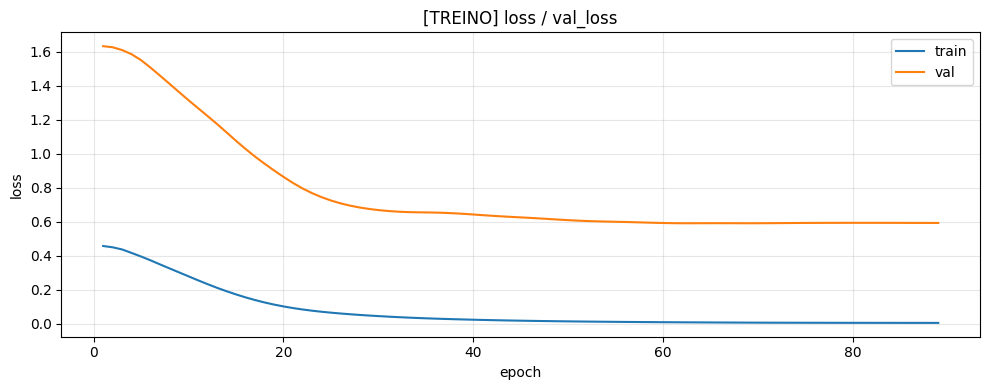

In [13]:
# ============================================================
# CÉLULA 11 — Treinar (Etapa 7) + plot loss/val_loss
# ============================================================

def plot_history(history, title_prefix=""):
    loss = history.history.get("loss", [])
    vloss = history.history.get("val_loss", [])
    epochs = np.arange(1, len(loss) + 1)

    fig = plt.figure(figsize=(10, 4))
    plt.plot(epochs, loss, label="train")
    plt.plot(epochs, vloss, label="val")
    plt.xlabel("epoch"); plt.ylabel("loss")
    plt.title(f"{title_prefix}loss / val_loss")
    plt.grid(True, alpha=0.3); plt.legend()
    plt.tight_layout()
    plt.show()

callbacks = build_callbacks(cfg)

history = model.fit(
    X_train_n, X_train_n,
    validation_data=(X_val_n, X_val_n),
    epochs=cfg.epochs,
    batch_size=cfg.batch,
    shuffle=cfg.shuffle,
    callbacks=callbacks,
    verbose=2,
)

plot_history(history, title_prefix="[TREINO] ")

In [14]:
# ============================================================
# CÉLULA 12 — Salvar modelos (Etapa 8)
# ============================================================
model_path = cfg.out_dir / f"{cfg.tag}.keras"
enc_path   = cfg.out_dir / "encoder.keras"

model.save(model_path)
encoder.save(enc_path)

print("✅ Model salvo :", model_path)
print("✅ Encoder salvo:", enc_path)

C:\Users\eldoj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)
C:\Users\eldoj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  retur

✅ Model salvo : C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\cavity_refinado\SAE\resultados\SAE\sae_dense.keras
✅ Encoder salvo: C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\cavity_refinado\SAE\resultados\SAE\encoder.keras


C:\Users\eldoj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)
C:\Users\eldoj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  retur

In [15]:
# ============================================================
# CÉLULA 13 — Latentes + Reconstrução (Etapa 9)
# ============================================================

z_train = encoder.predict(X_train_n, verbose=0)
z_val   = encoder.predict(X_val_n,   verbose=0)

lat_path = cfg.out_dir / "latents.npz"
np.savez_compressed(lat_path, t_train=t_train, t_val=t_val, z_train=z_train, z_val=z_val)

print("✅ z_train:", z_train.shape, "z_val:", z_val.shape)
print("✅ Latentes salvos em:", lat_path)

X_train_hat = model.predict(X_train_n, verbose=0)
X_val_hat   = model.predict(X_val_n,   verbose=0)

print("✅ Recon train:", X_train_hat.shape, "Recon val:", X_val_hat.shape)

✅ z_train: (8, 16) z_val: (3, 16)
✅ Latentes salvos em: C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\cavity_refinado\SAE\resultados\SAE\latents.npz
✅ Recon train: (8, 8192) Recon val: (3, 8192)


In [16]:
# ============================================================
# CÉLULA 14 — Diagnóstico (Etapa 10): métricas + outliers + plots
# ============================================================

def mse_per_sample(Xhat: np.ndarray, X: np.ndarray) -> np.ndarray:
    return np.mean((Xhat - X) ** 2, axis=1)

def rel_l2_per_sample(Xhat: np.ndarray, X: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    num = np.linalg.norm(Xhat - X, axis=1)
    den = np.linalg.norm(X, axis=1) + eps
    return num / den

def global_r2(Xhat: np.ndarray, X: np.ndarray, eps: float = 1e-12) -> float:
    Xh = Xhat.ravel()
    Xf = X.ravel()
    ss_res = np.sum((Xf - Xh) ** 2)
    ss_tot = np.sum((Xf - Xf.mean()) ** 2) + eps
    return float(1.0 - ss_res / ss_tot)

def topk_indices(x: np.ndarray, k: int) -> np.ndarray:
    k = min(k, len(x))
    return np.argsort(-x)[:k]

def save_recon_triplet_from_vector(vec_true, vec_recon, ny, nx, outpath: Path, title=""):
    outpath = Path(outpath)
    X = vec_true.reshape(ny, nx, 2)
    Xh = vec_recon.reshape(ny, nx, 2)

    # magnitude do vetor U
    Um  = np.sqrt(X[..., 0]**2  + X[..., 1]**2)
    Umh = np.sqrt(Xh[..., 0]**2 + Xh[..., 1]**2)

    fig, ax = plt.subplots(3, 3, figsize=(12, 9))

    # linha 1: Ux
    ax[0, 0].imshow(X[..., 0], origin="lower");  ax[0, 0].set_title("Ux true")
    ax[0, 1].imshow(Xh[..., 0], origin="lower"); ax[0, 1].set_title("Ux recon")
    ax[0, 2].imshow(Xh[..., 0] - X[..., 0], origin="lower"); ax[0, 2].set_title("Ux err")

    # linha 2: Uy
    ax[1, 0].imshow(X[..., 1], origin="lower");  ax[1, 0].set_title("Uy true")
    ax[1, 1].imshow(Xh[..., 1], origin="lower"); ax[1, 1].set_title("Uy recon")
    ax[1, 2].imshow(Xh[..., 1] - X[..., 1], origin="lower"); ax[1, 2].set_title("Uy err")

    # linha 3: U (magnitude)
    ax[2, 0].imshow(Um, origin="lower");  ax[2, 0].set_title("U true")
    ax[2, 1].imshow(Umh, origin="lower"); ax[2, 1].set_title("U recon")
    ax[2, 2].imshow(Umh - Um, origin="lower"); ax[2, 2].set_title("U err")

    for i in range(3):
        for j in range(3):
            ax[i, j].axis("off")

    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(outpath, dpi=150)
    plt.close(fig)

def analyze_training_errors(
    history,
    X_train_n, X_val_n,
    X_train_raw, X_val_raw,
    X_train_hat_n, X_val_hat_n,
    t_train, t_val,
    out_dir: Path,
    tag: str,
    ny: int, nx: int,
    mu: np.ndarray, sig: np.ndarray,
    outlier_topk: int = 5,
    save_outlier_images: bool = True
):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    outlier_dir = out_dir / "outliers"
    if save_outlier_images:
        outlier_dir.mkdir(parents=True, exist_ok=True)

    loss = np.array(history.history.get("loss", []), dtype=float)
    vloss = np.array(history.history.get("val_loss", []), dtype=float)
    epochs = np.arange(1, len(loss) + 1)

    gap = vloss - loss
    gap_rel = gap / (np.abs(vloss) + 1e-12)

    # loss curves (salvas)
    fig = plt.figure(figsize=(10, 4))
    plt.plot(epochs, loss, label="train")
    plt.plot(epochs, vloss, label="val")
    plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Loss vs epoch")
    plt.grid(True, alpha=0.3); plt.legend()
    fig.tight_layout(); fig.savefig(out_dir / f"{tag}_01_loss.png", dpi=150); plt.close(fig)

    # gap
    fig = plt.figure(figsize=(10, 4))
    plt.plot(epochs, gap, label="val - train")
    plt.xlabel("epoch"); plt.ylabel("gap"); plt.title("Generalization gap")
    plt.grid(True, alpha=0.3); plt.legend()
    fig.tight_layout(); fig.savefig(out_dir / f"{tag}_02_gap.png", dpi=150); plt.close(fig)

    # overfit score
    fig = plt.figure(figsize=(10, 4))
    plt.plot(epochs, gap_rel, label="gap / |val|")
    plt.xlabel("epoch"); plt.ylabel("relative gap"); plt.title("Overfitting score (relative gap)")
    plt.grid(True, alpha=0.3); plt.legend()
    fig.tight_layout(); fig.savefig(out_dir / f"{tag}_03_overfit_score.png", dpi=150); plt.close(fig)

    best_ep = int(np.argmin(vloss)) + 1 if len(vloss) else None

    # métricas por snapshot
    tr_mse = mse_per_sample(X_train_hat_n, X_train_n)
    va_mse = mse_per_sample(X_val_hat_n,   X_val_n)
    tr_rel = rel_l2_per_sample(X_train_hat_n, X_train_n)
    va_rel = rel_l2_per_sample(X_val_hat_n,   X_val_n)

    tr_r2 = global_r2(X_train_hat_n, X_train_n)
    va_r2 = global_r2(X_val_hat_n,   X_val_n)

    def plot_by_time(y_train, y_val, ylabel, title, fname):
        fig = plt.figure(figsize=(10, 4))
        plt.plot(t_train, y_train, "o-", label="train")
        plt.plot(t_val,   y_val,   "o-", label="val")
        plt.xlabel("tempo"); plt.ylabel(ylabel); plt.title(title)
        plt.grid(True, alpha=0.3); plt.legend()
        fig.tight_layout(); fig.savefig(out_dir / fname, dpi=150); plt.close(fig)

    plot_by_time(tr_mse, va_mse, "MSE", "MSE por snapshot (train vs val)", f"{tag}_04_mse_snapshot.png")
    plot_by_time(tr_rel, va_rel, "relL2", "Erro relativo L2 por snapshot (train vs val)", f"{tag}_05_relL2_snapshot.png")

    # histogramas
    fig = plt.figure(figsize=(8, 4))
    plt.hist(tr_rel, bins=30); plt.title("Hist relL2 (train)"); plt.xlabel("valor"); plt.ylabel("contagem")
    plt.grid(True, alpha=0.3); fig.tight_layout(); fig.savefig(out_dir / f"{tag}_06_hist_relL2_train.png", dpi=150); plt.close(fig)

    fig = plt.figure(figsize=(8, 4))
    plt.hist(va_rel, bins=30); plt.title("Hist relL2 (val)"); plt.xlabel("valor"); plt.ylabel("contagem")
    plt.grid(True, alpha=0.3); fig.tight_layout(); fig.savefig(out_dir / f"{tag}_07_hist_relL2_val.png", dpi=150); plt.close(fig)

    # outliers val (relat?rio geral em espa?o normalizado)
    va_bad = topk_indices(va_rel, outlier_topk)
    # imagens de campo: true em escala f?sica bruta, recon desnormalizada
    t_val_arr = np.asarray(t_val, dtype=float)
    mu_vec = np.asarray(mu, dtype=float).reshape(1, -1)
    sig_vec = np.asarray(sig, dtype=float).reshape(1, -1)

    X_val_phys = np.asarray(X_val_raw, dtype=float)
    X_val_hat_phys = np.asarray(X_val_hat_n, dtype=float) * sig_vec + mu_vec

    if X_val_phys.shape != X_val_hat_phys.shape:
        raise ValueError(
            f"Shape incompat?vel para imagens f?sicas: true={X_val_phys.shape}, recon={X_val_hat_phys.shape}"
        )

    idx_upto_5s = np.where(t_val_arr <= 5.0 + 1e-12)[0]

    if save_outlier_images and idx_upto_5s.size > 0:
        va_rel_phys_5s = rel_l2_per_sample(X_val_hat_phys[idx_upto_5s], X_val_phys[idx_upto_5s])
        n_sel = min(outlier_topk, idx_upto_5s.size)
        sel_local = np.argsort(-va_rel_phys_5s)[:n_sel]

        for rank, loc in enumerate(sel_local, start=1):
            i = int(idx_upto_5s[int(loc)])
            rel_i = float(va_rel_phys_5s[int(loc)])
            title = f"VAL <=5s outlier #{rank} | idx={i} | t={float(t_val_arr[i])} | relL2_phys={rel_i:.4f}"
            save_recon_triplet_from_vector(
                X_val_phys[i], X_val_hat_phys[i], ny, nx,
                outlier_dir / f"{tag}_val_outlier_upto5s_{rank:02d}_idx{i}.png",
                title=title,
            )


    metrics_path = out_dir / f"{tag}_metrics.npz"
    np.savez_compressed(
        metrics_path,
        loss=loss, val_loss=vloss, gap=gap, gap_rel=gap_rel,
        train_mse=tr_mse, val_mse=va_mse,
        train_relL2=tr_rel, val_relL2=va_rel,
        train_r2=np.array([tr_r2], dtype=np.float32),
        val_r2=np.array([va_r2], dtype=np.float32),
        val_bad_idx=va_bad,
        best_epoch=np.array([best_ep if best_ep is not None else -1], dtype=int),
    )

    print("\n======= DIAGNÓSTICO SAE =======")
    print(f"Melhor época (menor val_loss): {best_ep}")
    print(f"R² global: train={tr_r2:.4f} | val={va_r2:.4f}")
    print("Piores (val) relL2:", [(int(i), float(t_val[i]), float(va_rel[i])) for i in va_bad])
    print("Arquivos salvos em:", out_dir.resolve())
    print("===============================\n")
    return {"best_epoch": best_ep, "train_r2": tr_r2, "val_r2": va_r2, "metrics_path": metrics_path, "val_bad_idx": va_bad}


diag = analyze_training_errors(
    history=history,
    X_train_n=X_train_n, X_val_n=X_val_n,
    X_train_raw=X_train, X_val_raw=X_val,
    X_train_hat_n=X_train_hat, X_val_hat_n=X_val_hat,
    t_train=t_train, t_val=t_val,
    out_dir=cfg.out_dir,
    tag=cfg.tag,
    ny=cfg.ny, nx=cfg.nx,
    mu=mu, sig=sig,
    outlier_topk=cfg.outlier_topk,
    save_outlier_images=cfg.save_outlier_images,
)

diag



======= DIAGNÓSTICO SAE =======
Melhor época (menor val_loss): 69
R² global: train=0.7759 | val=0.6860
Piores (val) relL2: [(2, 0.9999799728393555, 0.6045083403587341), (1, 0.8999800086021423, 0.553080677986145), (0, 0.7999799847602844, 0.4545898735523224)]
Arquivos salvos em: C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\cavity_refinado\SAE\resultados\SAE



{'best_epoch': 69,
 'train_r2': 0.7758725881576538,
 'val_r2': 0.6859989166259766,
 'metrics_path': WindowsPath('C:/Users/eldoj/OneDrive/Documentos/SAE-POD-SINDy-main/cavity_refinado/SAE/resultados/SAE/sae_dense_metrics.npz'),
 'val_bad_idx': array([2, 1, 0])}